In [1]:
from scipy.signal import find_peaks
import pyabf
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [9]:
def plot_spiketrain(ax1, ax2, ax3, abf, sweepID, labelsize=10, ticksize=8):
    '''
    Plot the recorded waveform and the command waveform of the abf file.    
    '''


    #get the start and end time when sweepC is not zero
    diffC = np.abs(np.diff(abf.sweepC))
    start_time = abf.sweepX[np.where(diffC > 100 )[0][0]] -0.1
    end_time = abf.sweepX[np.where(diffC >100)[0][-1]] + 0.1

    #plot the recorded waveform
    
    abf.setSweep(sweepID) #the 11th sweep
    ax1.plot(abf.sweepX, abf.sweepY, color='#009FB9', lw=1)

    # Add an L-shaped scale bar
    scale_bar_length = 0.2  # 200 ms
    scale_bar_height = 20  # 20 mV

    # Calculate the coordinates for the scale bar
    x_start = end_time 
    y_start = -scale_bar_height//2
    x_end = end_time + scale_bar_length
    y_end = scale_bar_height

    # Add the scale bar to the plot
    ax1.plot([x_start, x_end], [y_start, y_start], color='black', lw=1)
    ax1.plot([x_end, x_end], [y_start, y_end], color='black', lw=1)

    # Add text labels for the scale bar
    ax1.text(x_end, y_start - 5, f'{int(scale_bar_length * 1000)} ms', ha='center', va='top', fontsize=ticksize)
    ax1.text(x_end+0.02, (y_start + y_end) / 2, f'{scale_bar_height} mV', ha='left', va='center', fontsize=ticksize)

    ax1.text(start_time, abf.sweepY[0]+10, f'{-60} mV', ha='right', va='center', fontsize=ticksize)

    #plot the command waveform
    
    ax2.plot(abf.sweepX, abf.sweepC, color='#F18D00', lw=1)

    #add 400 pA at the right side
    ax2.text(x_end, np.max(abf.sweepC), f'{400} pA', ha='center', va='center', fontsize=ticksize)

    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        #remove ticks
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(start_time-0.2, end_time+0.2)
        
        
    #plot the instantaneous firing rate
    #find the peaks of membrane potential
    mp_peaks, _ = find_peaks(abf.sweepY, distance=200, height=0) #height means we require the peak to be higher than 0 mV, that is the way to detect the peaks
    #calculate the spike time interval
    spike_time_interval = np.diff(abf.sweepX[mp_peaks])  
    #invert the spike time interval to get the firing rate
    firing_rate = 1/spike_time_interval
    spiketime = abf.sweepX[mp_peaks][1:]
    
    #scatter plot the firing rate against time 
    ax3.scatter(spiketime, firing_rate, color='#009FB9', s=10)    
    
    #now fit an exponential curve to the firing rate with A+B*exp(-t/tau), with parameters A, B and tau
    def exp_func(x, A, B, tau):
        return A + B*np.exp(-x/tau)
    
    popt, _ = curve_fit(exp_func, spiketime, firing_rate, p0=[0, 10000, 1])
    #add the fitted curve to the plot
    ax3.plot(spiketime, exp_func(spiketime, *popt), color='#F18D00', lw=2)
    #print A, B and tau
    print('A:', popt[0], 'B:', popt[1], 'tau:', popt[2])
    
    ax3.set_ylim(0, 50)
    ax3.set_yticks([0, 50])
    ax3.set_xlim(start_time-0.2, end_time+0.2)
    ax3.set_xticks([start_time, end_time])
    ax3.set_xticklabels([f'{0}', f'{int(1000*(end_time-start_time))}'], fontsize=ticksize)
    ax3.set_xlabel("Time (ms)", fontsize=labelsize)
    ax3.set_ylabel("Freq. (Hz)", fontsize=labelsize)
    #set tick font size
    ax3.tick_params(axis='both', which='major', labelsize=ticksize)
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)
    
    return ax1, ax2, ax3


A: 16.825972304534016 B: 619.9755611154204 tau: 0.3383130004547201


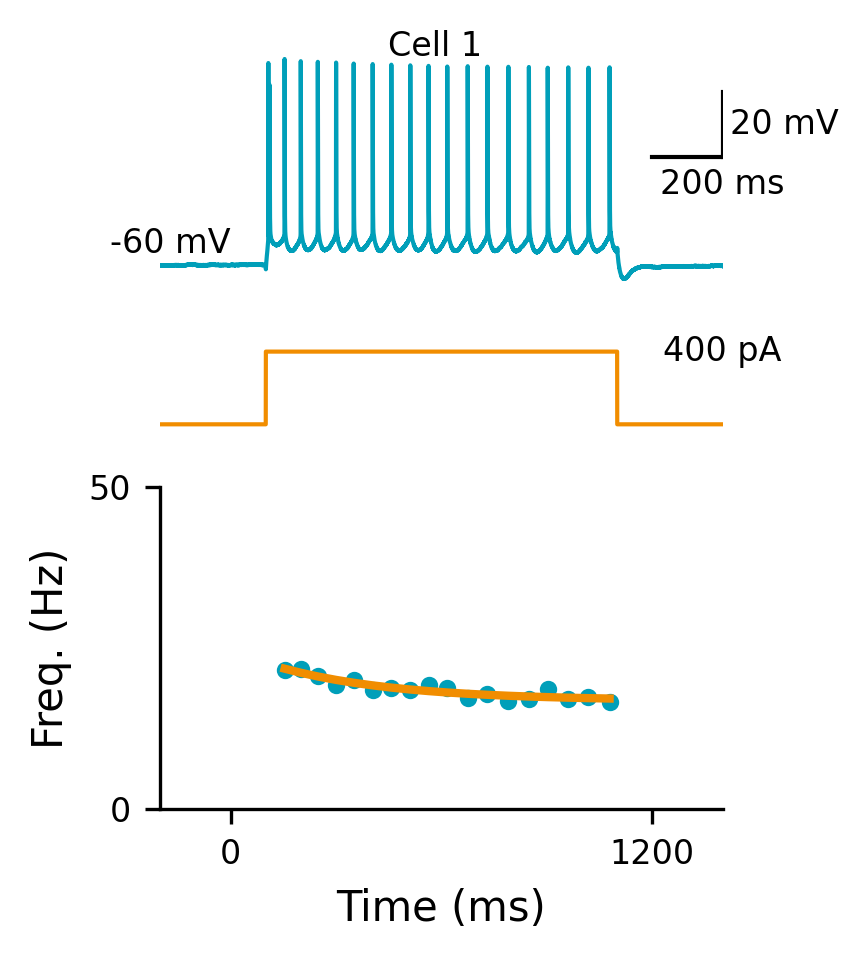

In [34]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(3, 3.5), dpi=300, height_ratios=[3, 1, 4])
labelsize = 10
ticksize = 8

# abf = pyabf.ABF("/home/zilong/Desktop/AnticipatoryCoding/NeuralData/YoshidaData/090323/cell3/09323026.abf")
# sweepID = 6
abf = pyabf.ABF("/home/zilong/Desktop/AnticipatoryCoding/NeuralData/YoshidaData/090604/cell1/09604005.abf")
sweepID = 10

ax1, ax2, ax3 = plot_spiketrain(ax1, ax2, ax3, abf, sweepID, labelsize=10, ticksize=8)

#add title
plt.suptitle('Cell 1', fontsize=8, y=0.9)

plt.tight_layout()

plt.savefig('/home/zilong/Desktop/AdaptiveAttractorForSequences/Figures/dorsalspiketrain_09604005.pdf', dpi=300)

A: 17.062521882824413 B: 1540176138.4556832 tau: 0.09058198118127872


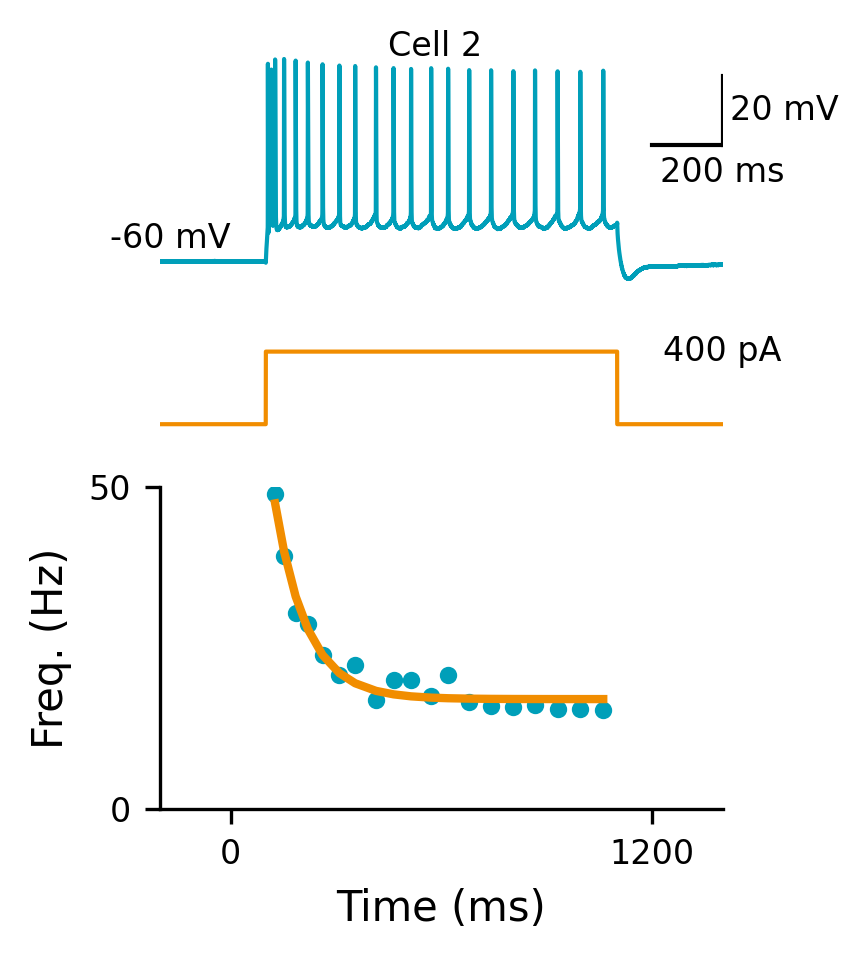

In [33]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(3,3.5), dpi=300, height_ratios=[3, 1, 4])
labelsize = 10
ticksize = 8

abf = pyabf.ABF("/home/zilong/Desktop/AnticipatoryCoding/NeuralData/YoshidaData/090318/cell2/09318014.abf")
sweepID = 9

ax1, ax2, ax3 = plot_spiketrain(ax1, ax2, ax3, abf, sweepID, labelsize=10, ticksize=8)

#add title
plt.suptitle('Cell 2', fontsize=8, y=0.9)

plt.tight_layout()

plt.savefig('/home/zilong/Desktop/AdaptiveAttractorForSequences/Figures/dorsalspiketrain_09318014.pdf', dpi=300)